# Exploratory Data Analysis of Cervical Cancer Risk Factors

## Objective
The goal of this project is to explore the Cervical Cancer Risk Factors dataset by cleaning the dataset, analyzing feature distrubtion, identifying correlation between variables, and finally examining associations with screening outcomes.

## Dataset
This project uses the **Cervical Cancer (Risk Factors)** dataset from the UCI Machine Learning Repository. 

Fernandes, K., Cardoso, J., & Fernandes, J. (2017). Cervical Cancer (Risk Factors) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5Z310.


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

In [101]:
df = pd.read_csv('risk_factors_cervical_cancer.csv', na_values='?')

## Initial Dataset Details
Before cleaning the dataset, inspect all its columns, datatypes, and missing values.

In [102]:
df.shape

(858, 36)

In [103]:
df.head(-1)

,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
2,34,1.0,NaN,1.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.00,0.0,...,NaN,NaN,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,43,3.0,17.0,3.0,0.0,0.0,0.0,1.0,5.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
853,34,3.0,18.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
854,32,2.0,19.0,1.0,0.0,0.0,0.0,1.0,8.00,0.0,...,NaN,NaN,0,0,0,0,0,0,0,0
855,25,2.0,17.0,0.0,0.0,0.0,0.0,1.0,0.08,0.0,...,NaN,NaN,0,0,0,0,0,0,1,0


In [104]:
df.columns

Index(['Age', 'Number of sexual partners', 'First sexual intercourse',
       'Num of pregnancies', 'Smokes', 'Smokes (years)', 'Smokes (packs/year)',
       'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD',
       'IUD (years)', 'STDs', 'STDs (number)', 'STDs:condylomatosis',
       'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis',
       'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis',
       'STDs:pelvic inflammatory disease', 'STDs:genital herpes',
       'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV',
       'STDs:Hepatitis B', 'STDs:HPV', 'STDs: Number of diagnosis',
       'STDs: Time since first diagnosis', 'STDs: Time since last diagnosis',
       'Dx:Cancer', 'Dx:CIN', 'Dx:HPV', 'Dx', 'Hinselmann', 'Schiller',
       'Citology', 'Biopsy'],
      dtype='object')

In [105]:
df.dtypes

Age                                     int64
Number of sexual partners             float64
First sexual intercourse              float64
Num of pregnancies                    float64
Smokes                                float64
Smokes (years)                        float64
Smokes (packs/year)                   float64
Hormonal Contraceptives               float64
Hormonal Contraceptives (years)       float64
IUD                                   float64
IUD (years)                           float64
STDs                                  float64
STDs (number)                         float64
STDs:condylomatosis                   float64
STDs:cervical condylomatosis          float64
STDs:vaginal condylomatosis           float64
STDs:vulvo-perineal condylomatosis    float64
STDs:syphilis                         float64
STDs:pelvic inflammatory disease      float64
STDs:genital herpes                   float64
STDs:molluscum contagiosum            float64
STDs:AIDS                         

In [106]:
df.isnull().sum()

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

## Data Cleaning
Now, it is time to start cleaning missing values by either removing columns entirely or imputing them with the median for quantitative variables and the mode for categorical variables. 

Since the two variables, STDs: Time since first diagnosis and STDs: Time since last diagnosis have around 92% of their data missing (787/857), they should be dropped since they have insufficient data for meaningful analysis.

In [107]:
df = pd.read_csv('risk_factors_cervical_cancer.csv', na_values='?')

df = df.drop(columns=['STDs: Time since first diagnosis', 'STDs: Time since last diagnosis'])

numcols = ['Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Smokes (packs/year)', 'Hormonal Contraceptives (years)', 'STDs (number)', 'IUD (years)']
df[numcols]=df[numcols].fillna(df[numcols].median())

catcols = ['Smokes', 'IUD', 'Hormonal Contraceptives', 'STDs', 'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV'] 
df[catcols] = df[catcols].fillna(df[catcols].mode().iloc[0])
df.isnull().sum()

Age                                   0
Number of sexual partners             0
First sexual intercourse              0
Num of pregnancies                    0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
IUD                                   0
IUD (years)                           0
STDs                                  0
STDs (number)                         0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0
STDs:genital herpes                   0
STDs:molluscum contagiosum            0
STDs:AIDS                             0
STDs:HIV                              0
STDs:Hepatitis B                      0
STDs:HPV                              0


After cleaning the missing values, the dataset is now ready for analysis.

In [108]:
# statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,858.0,26.820513,8.497948,13.0,20.0,25.0,32.0,84.0
Number of sexual partners,858.0,2.511655,1.644759,1.0,2.0,2.0,3.0,28.0
First sexual intercourse,858.0,16.995338,2.791883,10.0,15.0,17.0,18.0,32.0
Num of pregnancies,858.0,2.257576,1.400981,0.0,1.0,2.0,3.0,11.0
Smokes,858.0,0.143357,0.350641,0.0,0.0,0.0,0.0,1.0
Smokes (years),858.0,1.201241,4.060623,0.0,0.0,0.0,0.0,37.0
Smokes (packs/year),858.0,0.446278,2.210351,0.0,0.0,0.0,0.0,37.0
Hormonal Contraceptives,858.0,0.686480,0.464194,0.0,0.0,1.0,1.0,1.0
Hormonal Contraceptives (years),858.0,2.035331,3.567040,0.0,0.0,0.5,2.0,30.0
IUD,858.0,0.096737,0.295771,0.0,0.0,0.0,0.0,1.0


From the statistics of the data, several interesting findings were observed. These include the following: 

* The mean age of the participants is around 27 years old, and 75% of participants being under 32. Since the maximum of this variable is 84 years, the data appears to be skewed right due to a small amount of older participants.
* A majority of the participants have not reported smoking, and the median smokes/year is 0 while the mean is around 1.2, meaning the data is heavily skewed right.
* Positive Hinselmann, Schiller, Citology, and Biopsy cases are relatively rare, meaning negative test cases dominate the data. This  creates a class imbalance in the target variables and might affect the performance and evaluation of any future predictive analysis

## Distribution of Target Variables

The 4 target variables (Hinselmann, Schiller, Citology, and Biopsy) are analyzed.

In [109]:
# Counts for our target variables
[df[col].value_counts() for col in ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']]

[Hinselmann
 0    823
 1     35
 Name: count, dtype: int64,
 Schiller
 0    784
 1     74
 Name: count, dtype: int64,
 Citology
 0    814
 1     44
 Name: count, dtype: int64,
 Biopsy
 0    803
 1     55
 Name: count, dtype: int64]

In [110]:
corr = df.corr()
corr.shape

(34, 34)

In [111]:
# Finding the correlation between the target variables and other factors
targets = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']
corr[targets].sort_values(by = 'Biopsy', ascending=False)

,Hinselmann,Schiller,Citology,Biopsy
Biopsy,0.547417,0.733204,0.327466,1.000000
Schiller,0.650249,1.000000,0.361486,0.733204
Hinselmann,1.000000,0.650249,0.192467,0.547417
Citology,0.192467,0.361486,1.000000,0.327466
Dx:Cancer,0.134264,0.157812,0.113446,0.160905
Dx:HPV,0.134264,0.157812,0.113446,0.160905
Dx,0.072215,0.098952,0.088740,0.157607
STDs:genital herpes,-0.007044,-0.010495,-0.007942,0.130523
STDs:HIV,0.093151,0.128842,0.076576,0.127702
STDs,0.056599,0.117552,0.053889,0.114148


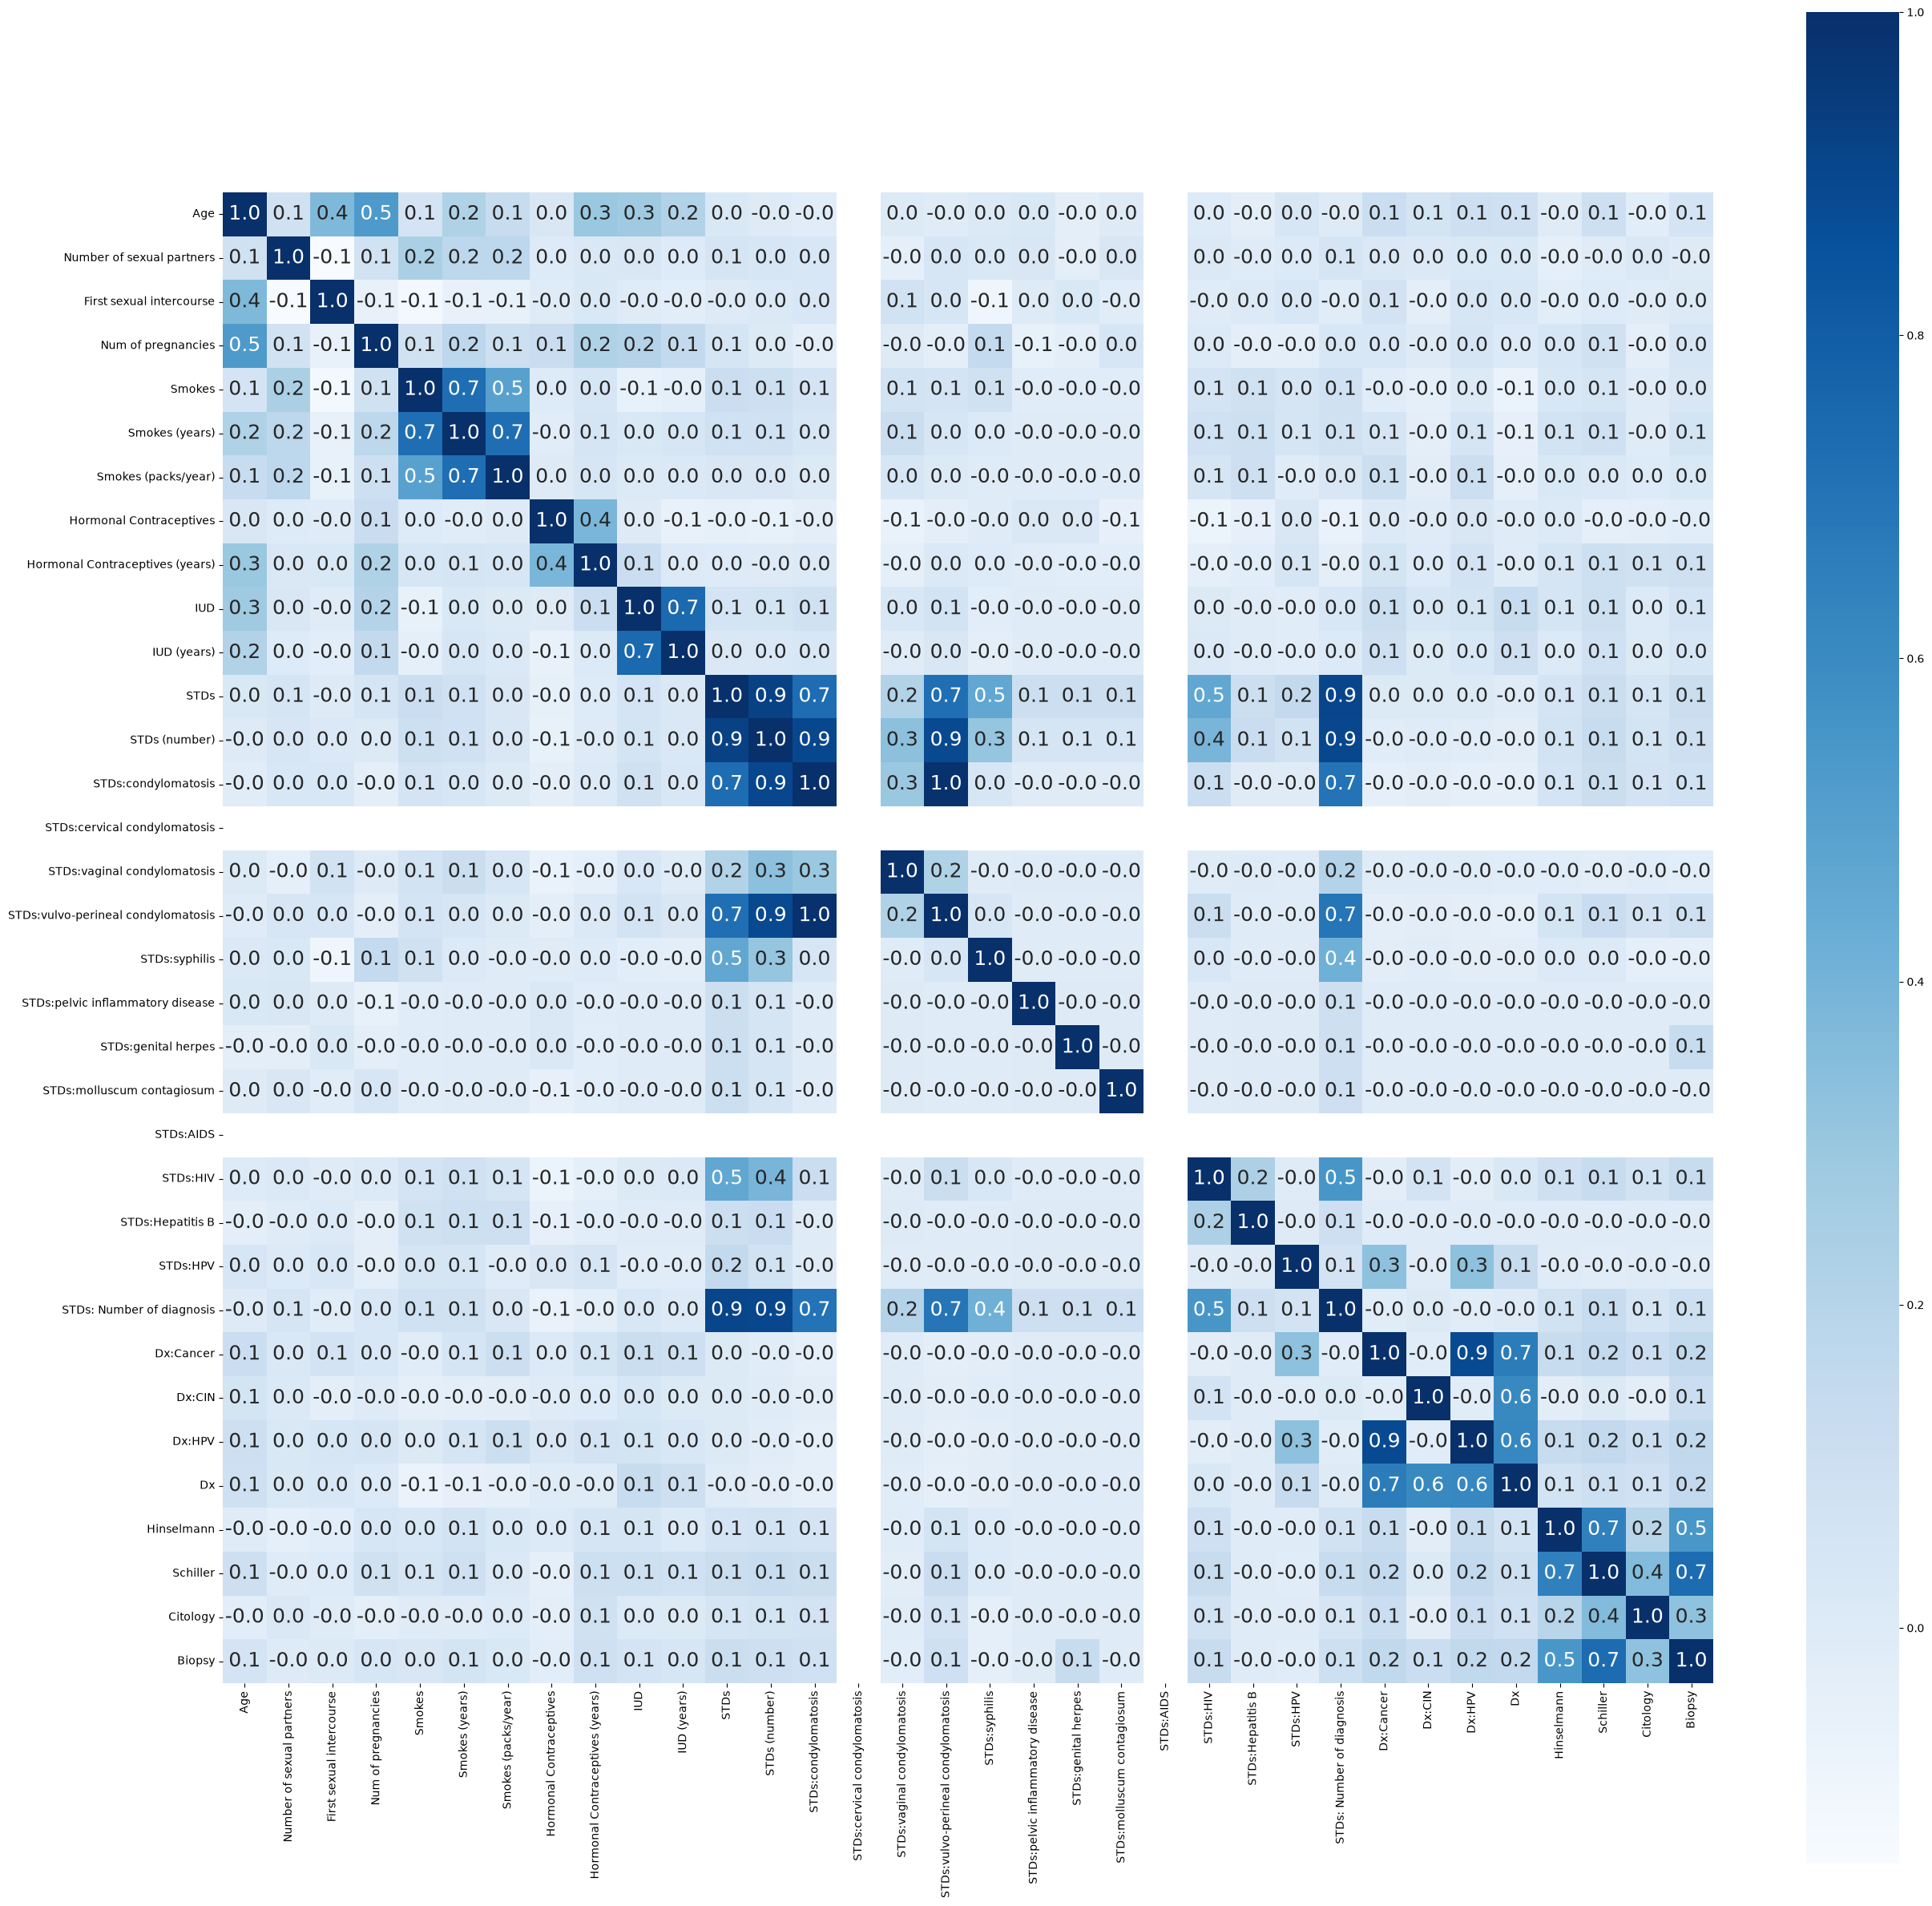

In [112]:
# Heatmap
plt.figure(figsize=(30,30))
sns.heatmap(corr, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':18}, cmap='Blues')
plt.show()

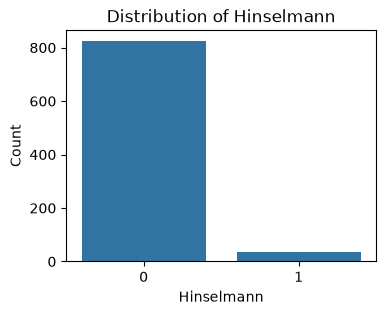

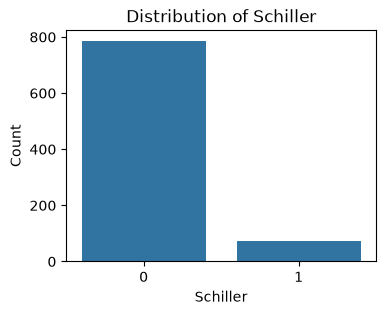

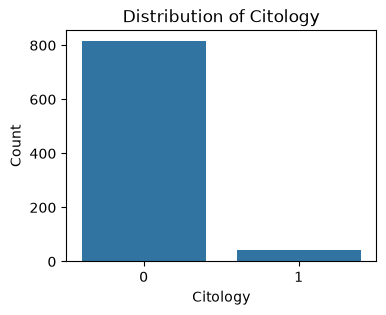

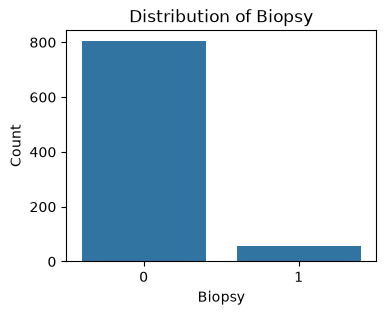

In [113]:
# Countplot
targets = ['Hinselmann', 'Schiller', 'Citology', 'Biopsy']

for target in targets:
    plt.figure(figsize=(4,3))
    sns.countplot(x=target, data=df)
    plt.title(f'Distribution of {target}')
    plt.xlabel(target)
    plt.ylabel('Count')
    plt.show()

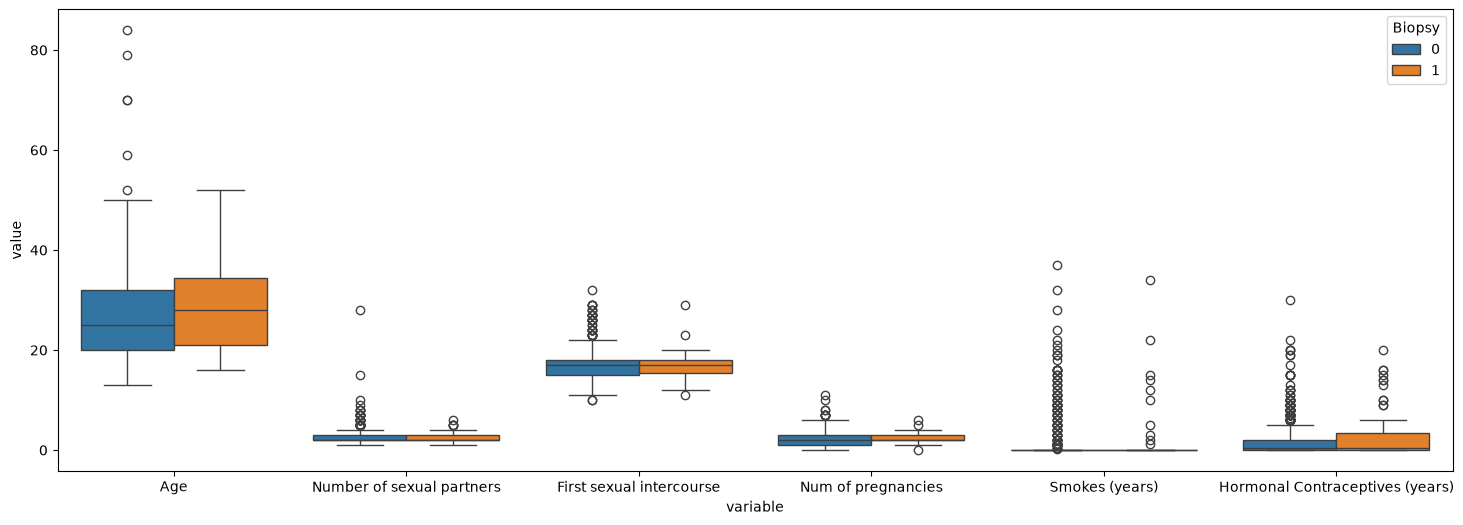

In [114]:
# Boxplot
melted_data = pd.melt(df, id_vars='Biopsy', value_vars=['Age', 'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 'Smokes (years)', 'Hormonal Contraceptives (years)'])
plt.figure(figsize=(18,6))
sns.boxplot(
    x="variable",
    y="value",
    hue="Biopsy",
    data=melted_data)
plt.show()

The boxplots show the distribution of the given variables are very similar for patients with positive and negative biopsy test results. Because of this and the major overlap between the groups, it can be concluded that the variables are not clear factors to distinguish between biopsy outcomes. This is consistent with the previous correlation analysis, where the correlation coefficients between these variables and Biopsy were usually weak (most r<0.15). 

## Overall Findings
* The data originally contained features with a majority of their data missing, which were removed.
* Remaining missing values in other columns were imputed with the median and mode of their features.
* Positive Hinselmann, Schiller, Citology, and Biopsy tests accounted for a small percentage of the total observations (as shown by the countplots), meaning there is heavy class imbalance.
* A majority of the varibles have a weak correlation with the biopsy outcomes, which is important for any future predictive analysis.
* The boxplots show large amounts of overlap between positive and negative biopsy groups, which suggests that from the selected variables, no single feature clearly seperates the classes.